## Random Seed

In [1]:
import random
import torch
import numpy as np
import json


In [2]:
print(torch.__version__)

2.7.0+cu128


In [3]:

def set_seed(seed):
    # 設定 Python 隨機數生成器的種子
    random.seed(seed)
    
    # 設定 numpy 隨機數生成器的種子
    np.random.seed(seed)
    
    # 設定 PyTorch 隨機數生成器的種子
    torch.manual_seed(seed)
    
    # 如果使用 GPU，設置 CUDA 隨機數生成器的種子
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 設置 PyTorch 預測模式，保證可重現性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 設定隨機種子
set_seed(22)


## Dataset

In [4]:
from transformers import AutoTokenizer
import torch

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/sec-bert-base")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

/service/mo1om/miniconda/envs/t5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# batch
from concurrent.futures import ThreadPoolExecutor
import math
from tqdm import tqdm

def process_batch(batch, target_attrs, tokenizer):

    batch_results = []
    for job in batch:
        context_p = job['context'].get("context_p", "")
        context_t = job['context'].get("context_t", "")
        context_n = job['context'].get("context_n", "")
        # full_context = f"{context_t} [SEP] {context_p} [SEP] {context_n}"
        document_info = f"{job['document']['document_type']};{job['document']['period_end_date']};{job['document']['fiscal_year']};{job['document']['period_focus']}"
        full_context = f"{context_t} [SEP] {document_info} [SEP] {context_p} [SEP] {context_n}"

        tokenized = tokenizer(
            full_context,
            padding = "max_length",
            truncation = True,
            max_length = 512,
            return_tensors = "pt",
            return_offsets_mapping = True,
            return_special_tokens_mask = True,
        )

        token_ids = tokenized["input_ids"].squeeze(0)
        offset_mapping = tokenized["offset_mapping"].squeeze(0)

        # sep_indices = [idx for idx, token in enumerate(token_ids) if token == tokenizer.sep_token_id]
        # context_t_end = sep_indices[0] if sep_indices else len(token_ids) - 1
        
        for i, target in enumerate(job['targets']):
            start_char, end_char = target['start_pos'], target['end_pos']
            start_token, end_token = -1, -1

            for idx, (start, end) in enumerate(offset_mapping):
                # if idx > context_t_end:
                #     break
                if start <= start_char < end:
                    start_token = idx
                if start < end_char <= end:
                    end_token = idx
                    break
            
            # if start_token == -1 or end_token == -1 or start_token > context_t_end or end_token > context_t_end:
            if start_token == -1 or end_token == -1:
                continue 
                
            # print("\n=== DEBUG: Tokenization ===")
            # token_ids = tokenized["input_ids"].squeeze(0) 
            # tokens = tokenizer.convert_ids_to_tokens(token_ids.tolist())
            # print("Original Text:", full_context)
            # # print("Tokens:", tokens)
            # print("Offset Mapping:", offset_mapping)
            # print(f"Target Text: {target['text']} | Start Char: {start_char}, End Char: {end_char}")
            # print(f"Found Token Indices -> Start: {start_token}, End: {end_token}")
            # if start_token >= 0 and end_token >= 0:
            #     print(f"Matched Tokens: {tokens[start_token:end_token+1]}")
            # print("====================================\n")
            
            target_data = {
                "job_id": job["job_id"],
                "seq_id": target["seq_id"],
                "context": full_context,
                "input_ids": token_ids,
                "attention_mask": tokenized['attention_mask'].squeeze(0),
                "start_token": start_token,
                "end_token": end_token,
                "value": convert_span_to_number(target['text']),
                "doc_link": job['document']['document_link'],
            }
            
            for attr in target_attrs:
                if attr in ["tag", "time", "scale", "negative"]:  # 分類屬性
                    target_data[attr] = CLASSIFICATION_MISSING_VALUE
                elif attr == "fact":  # 數值屬性
                    target_data[attr] = NUMERIC_MISSING_VALUE

            gold_values = job['golds'][i]['value']
            for attr_idx, attr in enumerate(target['attribute']):
                value = gold_values[attr_idx]
                if attr == 'tag':
                    # 暫時先歸到 standard_rare 
                    if value in standard_rare_tags:
                        value = 'standard_rare'
                    target_data['tag'] = tag2id.get(value, -100)
                elif attr == 'time':
                    target_data['time'] = time2id.get(value, -100)
                elif attr == 'fact':
                    if value:
                        target_data['fact'] = float(value)
                        target_data['negative'] = 1 if value < 0 else 0
                    else:
                        target_data['fact'] = NUMERIC_MISSING_VALUE
                        target_data['negative'] = CLASSIFICATION_MISSING_VALUE
                    # target_data['fact'] = float(value)
                elif attr == 'scale':
                    target_data['scale'] = scale2id.get(value, -100)

               
                    
            batch_results.append(target_data)
    return batch_results

from concurrent.futures import ProcessPoolExecutor, TimeoutError


def process_batch_wrapper(args):
    """ 用於 `ProcessPoolExecutor` 的批次處理函數 """
    batch, target_attrs, tokenizer = args
    return process_batch(batch, target_attrs, tokenizer)

def process_data(data, target_attrs, tokenizer, batch_size = 32, num_workers = 8):
    inputs = []
    
    # 計算總批次數
    num_batches = math.ceil(len(data) / batch_size)

    # 將數據拆分成批次
    batches = [data[i * batch_size: (i + 1) * batch_size] for i in range(num_batches)]

    # 構建參數列表
    task_args = [(batch, target_attrs, tokenizer) for batch in batches]

    # 使用多進程處理批次
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(process_batch_wrapper, task_args), total=num_batches, desc="Processing Data"))

    # 合併所有批次的結果
    for res in results:
        inputs.extend(res)
    
    return inputs


In [6]:
# IterableDataset

with open('../processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
# with open('../processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:    
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


In [7]:
import locale
from word2number import w2n

def convert_span_to_number(span):
    """
    將 span 轉換為數字。
    """
    span = span.strip()
    
    # 嘗試直接轉換為數字
    try:
        return locale.atof(span.replace(",", ""))  # 去掉千分位逗號並轉換
    except ValueError:
        pass  # 不是標準數字，繼續嘗試解析
    
    # 嘗試將文字轉為數字
    try:
        return w2n.word_to_num(span.lower())
    except ValueError:
        pass  # 不是可解析的數字
    
    return None  # 解析失敗，返回 None


#### IterableDataset

In [8]:
import random
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class MultiTaskIterableDataset(IterableDataset):
    ''' 讀取原始 JSONL 檔案，進行前處理'''

    def __init__(self, files, target_attrs, tokenizer, batch_size=32, num_workers=8):
        self.files = files
        self.target_attrs = target_attrs
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers
    
    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line
    def __iter__(self):
        """逐行讀取 JSONL 並轉換為數據格式"""
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)
                processed_data = process_batch([raw_data], self.target_attrs, self.tokenizer)
                for item in processed_data:
                    yield item
                    
class BufferedShuffleDataset(IterableDataset):
    """ 負責對 IterableDataset 進行 buffer shuffle """

    def __init__(self, dataset, buffer_size = 8000):
        self.dataset = dataset
        self.buffer_size = buffer_size

    def __iter__(self):
        buffer = []
        for sample in self.dataset:
            buffer.append(sample)
            if len(buffer) >= self.buffer_size:
                random.shuffle(buffer)
                while buffer:
                    yield buffer.pop()

        random.shuffle(buffer)
        while buffer:
            yield buffer.pop()

In [9]:
batch_size = 256
num_workers = 4
target_attrs = ["tag", "time", "scale", "negative", "fact"]

train_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/train_400k.jsonl"], 
    # files = ["processed_data_task1/train_data_shuffled.jsonl"],
    target_attrs = target_attrs,
    tokenizer = tokenizer)

valid_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/valid_50k.jsonl"], 
    # files = ["processed_data_task1/valid_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)

test_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/test_50k.jsonl"], 
    # files = ["processed_data_task1/test_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers)
valid_dataloader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = num_workers)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers)

#### Load Processed Iterable Dataset

In [12]:
# 讀取處理後的 JSONL

import json
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class ProcessedIterableDataset(IterableDataset):
    def __init__(self, files):
        self.files = files

    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line

    def __iter__(self):
        """讀取 JSONL 並轉換為合適格式"""
        sample_count = 0
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)

                # 把 list 轉回 torch.Tensor
                processed_data = {
                    key: torch.tensor(value) if isinstance(value, list) else value
                    for key, value in raw_data.items()
                }
                
                yield processed_data

            

train_files = ["processed_iterable_dataset/train_400k.jsonl"]
valid_files = ["processed_iterable_dataset/valid_50k.jsonl"] 
test_files = ["processed_iterable_dataset/test_50k.jsonl"]

train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 256
# train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

In [11]:
import os

def count_lines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

# 計算訓練資料大約的 batch 數
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")

Train 預計數量: 728821, 預計 2846 個 batch
Valid 預計數量: 91168, 預計 356 個 batch
Test 預計數量: 90337, 預計 352 個 batch


## Count

#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [13]:
# load counter result

def load_counter(target_attr):
    target_path = f'processed_iterable_dataset/counter/secbert_train_small_{target_attr}.json'

    with open(target_path, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

train_tag_counts = load_counter("tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print(f'Total tag class: {len(train_tag_counts)}')
train_time_counts = load_counter("time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print(train_time_counts)

train_neg_counts = load_counter("negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print(train_neg_counts)

train_scale_counts = load_counter("scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print(train_scale_counts)

Total tag class: 978
{'6': 70691, '4': 124746, '3': 175155, '1': 195615, '0': 135307, '2': 14182, '5': 10629, '7': 351, '8': 490}
{'0': 701747, '1': 19527}
{'18': 328811, '10': 117673, '12': 152722, '15': 50895, '21': 18758, '8': 1695, '17': 38, '14': 13, '9': 20, '11': 18, '13': 17, '24': 30, '16': 37, '20': 2, '6': 5, '19': 3}


## Model

In [14]:
import torch
import torch.nn as nn
from transformers import BertModel, BertPreTrainedModel

class GateHead(nn.Module):
    """
    The Gating MLP from the whiteboard.
    Input: [CLS] token representation
    Output: A score between 0 and 1 representing 'Noise Probability' (e_i).
            1 = High Noise (Ignore this sample)
            0 = Clean Data (Learn from this sample)
    """
    def __init__(self, hidden_size, dropout_prob=0.1):
        super().__init__()
        self.dense = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.out_proj = nn.Linear(hidden_size, 1) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x) # Tanh is standard for BERT pooler/heads
        x = self.dropout(x)
        x = self.out_proj(x)
        return self.sigmoid(x)



In [15]:
import torch.nn as nn
from transformers import BertModel

class MultiTaskModel(nn.Module):
    def __init__(self, bert_model_name, num_tags, num_times, num_scales):
        super(MultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden_size = self.bert.config.hidden_size
        
        self.tag_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_tags)
        )

        self.time_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_times)
        )

        self.scale_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, num_scales)
        )

        self.negative_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, 2)
        )
        self.gate_head = GateHead(hidden_size)
        
    def forward(self, input_ids, attention_mask, start_tokens, end_tokens):
        # BERT output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        cls_token = sequence_output[:, 0, :]
        # Aggrerate target embeddings
        target_embeddings = [
            sequence_output[i, start_tokens[i]:end_tokens[i] + 1].mean(dim=0)
            for i in range(input_ids.size(0))
        ] # batch_size 個 tensor，tensor size: (hidden_size,) 
        
        target_embeddings = torch.stack(target_embeddings) # 轉成 Liner Layer 的 input (batch_size, hidden_size)
        
        tag_logits = self.tag_head(target_embeddings)
        time_logits = self.time_head(target_embeddings)
        # 預測 scale
        
        scale_logits = self.scale_head(target_embeddings)  # (batch_size, num_scales)
        negative_logits = self.negative_head(target_embeddings)
        gate_logits = self.gate_head(cls_token)
        
        return {
            "tag": tag_logits,
            "time": time_logits,
            "scale": scale_logits,
            "negative": negative_logits,
            "gate": gate_logits
        }


## Loss

In [16]:
# hits@k
import torch

def hits_at_k(predictions, targets, k=5):
    """
    計算 Hits@K 指標
    :param predictions: (batch_size, num_tags) - 預測分數
    :param targets: (batch_size, num_tags) - 目標標籤 (one-hot 或 multi-hot)
    :param k: 取前 K 個預測標籤
    :return: Hits@K 平均值
    """
    valid_mask = targets != -100  # 只保留有效的索引
    targets = targets[valid_mask]
    predictions = predictions[valid_mask]
    # print(f"targets.shape: {targets.shape}, targets min: {targets.min()}, targets max: {targets.max()}")
    # assert targets.min() >= 0, f"targets 包含負數: {targets}"

    top_k_preds = torch.topk(predictions, k, dim=-1).indices  # 取得 top-K 標籤索引

       # 確保 targets 維度正確
    if targets.dim() == 1:  # 若 targets 是索引格式 (batch_size,)
        targets = torch.nn.functional.one_hot(targets, num_classes=predictions.size(1))

    targets = targets.float()  # 確保是 float tensor

    # 判斷是否命中 top-K (batch_size, k) → (batch_size,)
    hits = torch.any(targets.gather(1, top_k_preds), dim=1).float()

    return hits.mean().item()  # 計算平均命中率

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# device = 'cpu'

cuda


In [18]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.90167407 1.         1.         2.15193528
 1.5        5.44323412 5.11132642]


In [19]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [20]:
# # netagive loss

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     '''https://doi.org/10.1109/tpami.2018.2858826'''
#     def __init__(self, alpha=0.25, gamma=2.0, reduction="mean", ignore_index = CLASSIFICATION_MISSING_VALUE):
#         """
#         alpha: 平衡因子 (適用於正負類不平衡)
#         gamma: 縮放因子 (讓難分類的樣本 loss 權重變高)
#         reduction: 可選 ["mean", "sum", "none"]，控制 loss 的輸出方式
#         """
#         super(FocalLoss, self).__init__()
#         if isinstance(alpha, (float, int)):  # 確保 alpha 是 tensor
#             self.alpha = torch.tensor([1 - alpha, alpha])  # alpha_neg, alpha_pos
#         else:
#             self.alpha = torch.tensor(alpha) 
#         self.gamma = gamma
#         self.reduction = reduction
#         self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=CLASSIFICATION_MISSING_VALUE)
#         self.ignore_index = ignore_index

#     def forward(self, logits, targets):
#         """
#         logits: 預測值 (模型輸出，形狀 [batch_size, 2]，未經 softmax)
#         targets: 標籤值 (形狀 [batch_size]，0 或 1)
#         """
#         device = logits.device
#         self.alpha = self.alpha.to(device)
#         # print('focal loss', targets)
#         # print(targets.shape)
#         if targets.dim() > 1:
#             targets = targets.argmax(dim=-1)
        
#          # 1. 移除 ignore_index
#         valid_mask = (targets != self.ignore_index)
#         targets = targets[valid_mask]
#         logits = logits[valid_mask]

#         # if targets.numel() == 0:  # 避免 loss 計算時出現空值
#         #     return torch.tensor(0.0, device=device, requires_grad=True)
#         # if torch.any(filtered_targets < 0) or torch.any(filtered_targets >= logits.shape[-1]):
#         #     raise ValueError(f"Invalid target values detected: {filtered_targets}")
        
#         # 2. 計算 CrossEntropyLoss
#         ce_loss = self.ce_loss(logits, targets)  # 計算 cross entropy loss
#         pt = torch.exp(-ce_loss)  # 選擇正確類別的機率
        
#         # 4. 計算 focal loss 權重
#         focal_weight = (1 - pt) ** self.gamma  # (1 - p_t)^gamma
#         alpha_weight = self.alpha.gather(0, targets.data.view(-1))  # 根據 targets 索引 alpha

#         loss = alpha_weight * focal_weight * ce_loss

#         # 5. 根據 reduction 返回 loss
#         if self.reduction == "mean":
#             return loss.mean() if loss.numel() > 0 else torch.tensor(0.0, device=device, requires_grad=True)
#         elif self.reduction == "sum":
#             return loss.sum()
#         else:
#             return loss  # 不做平均，返回 batch loss

# neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="mean")

In [21]:
# # tag loss
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class CB_CE_Loss(nn.Module):
#     '''
#     https://ieeexplore.ieee.org/abstract/document/8953804
#     '''
#     def __init__(self, num_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE):
#         """
#         Args:
#             num_samples: list or tensor, 每個類別的樣本數
#             beta: 控制 class-balanced 權重的超參數 (通常取 0.99)
#         """
#         super(CB_CE_Loss, self).__init__()
        
#         # 計算 Class-Balanced 權重
#         effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
#         weights = (1.0 - beta) / (effective_num + 1e-8)
#         # self.weights = weights / torch.sum(weights)  # normalize
#         self.weights = weights
#         self.ignore_index = ignore_index
        
#     def forward(self, logits, targets):
#         """
#         Args:
#             logits: (batch_size, num_classes) 模型輸出的 logits
#             targets: (batch_size,) 類別索引標籤
#         Returns:
#             CB-CE Loss 值
#         """
        
#         if targets.dim() > 1:
#             targets = targets.argmax(dim=-1)
            
#         valid_mask = (targets != self.ignore_index)  # 只對有效的 targets 計算 loss
#         targets = targets[valid_mask]
#         logits = logits[valid_mask]
        
#         # 計算標準 CE Loss
#         ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
#         # 依照類別權重調整 loss
#         class_weights = self.weights.to(logits.device)
#         weighted_loss = ce_loss * class_weights[targets]
        
#         # weighted_loss = ce_loss * class_weights[targets] * weight_mask.float()
#         return torch.mean(weighted_loss)

#         # return weighted_loss.sum() / weight_mask.sum()  # 只對有效樣本取平均

# # train_tag_counts = get_value_counts(train_loader, "tag")
# # num_tag_samples = [train_tag_counts.get(tag, 0) for tag in sorted(train_tag_counts.keys())]  # 確保對應到索引順序
# tag_loss_fn = CB_CE_Loss(num_tag_samples, beta = 0.99)

In [22]:
# # train_time_counts = get_value_counts(train_loader, "time")
# # num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
# time_loss_fn = CB_CE_Loss(num_time_samples)

In [23]:
# fact loss

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = torch.abs(error) < delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (torch.abs(error) - 0.5 * delta)
    return torch.where(is_small_error, squared_loss, linear_loss).mean()

def signed_log(x):
    return torch.sign(x) * torch.log1p(torch.abs(x))  # 保留正負號

def fact_loss_fn(fact_pred, fact_target):
    # 過濾特殊值
    valid_mask = fact_target != NUMERIC_MISSING_VALUE
    fact_pred = fact_pred[valid_mask]
    fact_target = fact_target[valid_mask]
    
    #  signed log 轉換
    fact_target_log = signed_log(fact_target)
    fact_pred_log = signed_log(fact_pred)

    #  # 設定 Hybrid Loss 的閾值
    threshold = 8.0

    # # 小於 threshold 用 Huber Loss，大於 threshold 用 MSE
    use_huber = fact_target_log.abs() < threshold
    use_mse = ~use_huber

    huber_part = huber_loss(fact_pred_log[use_huber], fact_target_log[use_huber]) if use_huber.any() else 0
    mse_part = mse_loss(fact_pred_log[use_mse], fact_target_log[use_mse]) if use_mse.any() else 0

    # 最終 loss
    return huber_part + mse_part
    

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. Focal Loss (Updated for reduction='none') ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="none", ignore_index=-100):
        super(FocalLoss, self).__init__()
        # ... (init logic same as before) ...
        if isinstance(alpha, (float, int)): 
            self.alpha = torch.tensor([1 - alpha, alpha])
        else:
            self.alpha = torch.tensor(alpha)
        self.gamma = gamma
        self.reduction = reduction # Default is now 'none'
        self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index)
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        device = logits.device
        self.alpha = self.alpha.to(device)
        
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        # Standard Cross Entropy (Returns vector [batch_size])
        ce_loss = self.ce_loss(logits, targets) 
        pt = torch.exp(-ce_loss)
        
        # Calculate weights
        focal_weight = (1 - pt) ** self.gamma
        
        # Handle ignore_index safely for alpha lookup
        # We clamp target indices just for the lookup to avoid crash, the loss will be masked anyway by ce_loss
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0 
        alpha_weight = self.alpha.gather(0, safe_targets.view(-1))
        
        loss = alpha_weight * focal_weight * ce_loss
        
        # Mask out ignore_index manually since alpha lookup might have been affected
        loss = torch.where(targets != self.ignore_index, loss, torch.zeros_like(loss))

        if self.reduction == "mean":
            return loss.sum() / (targets != self.ignore_index).sum()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss  # Returns [batch_size]

# --- 2. Class Balanced Loss (Updated for reduction='none') ---
class CB_CE_Loss(nn.Module):
    def __init__(self, num_samples, beta=0.99, ignore_index=-100):
        super(CB_CE_Loss, self).__init__()
        effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
        weights = (1.0 - beta) / (effective_num + 1e-8)
        self.weights = weights
        self.ignore_index = ignore_index
        
    def forward(self, logits, targets):
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        # Calculate standard CE Loss (Vector)
        ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
        # Class Weights
        class_weights = self.weights.to(logits.device)
        
        # Safe lookup for weights (handle ignore_index)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        sample_weights = class_weights[safe_targets]
        
        weighted_loss = ce_loss * sample_weights
        
        # Ensure ignored indices are truly 0
        weighted_loss = torch.where(targets != self.ignore_index, weighted_loss, torch.zeros_like(weighted_loss))
        
        return weighted_loss # Returns [batch_size]

In [25]:
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [26]:
# # loss function

# classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
# mse_loss = nn.MSELoss()

# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         # if not model.training:
#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
#     if "negative" in targets:
#         # 負號預測
#         negative_pred = outputs["negative"].argmax(dim=-1)  # [batch_size]
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     total_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # 平衡 loss 避免變大
#     total_loss = total_loss / sum(task_weights.values())

#     # print('total_loss', total_loss)
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)

In [27]:
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [28]:
CLASSIFICATION_MISSING_VALUE=-100
classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()


In [29]:
def compute_loss(outputs, targets, values, task_weights=None, hits_k=False):
    losses = {}
    
    # --- 1. Calculate Raw Vector Losses [batch_size] ---
    if "tag" in targets:
        losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

    if "time" in targets:
        losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
    if "scale" in targets:
        losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
    if "negative" in targets:
        losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
    # --- 2. Aggregate Losses Per Sample ---
    # gate: [batch_size, 1] -> [batch_size]
    gate = outputs["gate"].squeeze(-1)
    
    # Initialize total_raw_loss as a vector of zeros on the correct device
    total_raw_loss = torch.zeros_like(gate)
    
    for k in losses.keys():
        # Add weighted task loss (Vector addition)
        total_raw_loss += task_weights[k] * losses[k]
        
    # --- 3. Apply Gate Mechanism (Sample-wise) ---
    # (1 - gate) * sample_loss + gate^2
    # This weights EASY samples (high gate) less on the main loss, but penalizes the gate itself
    weighted_loss_vec = (1 - gate) * total_raw_loss + gate.pow(2)
    
    # --- 4. Final Average & Normalization ---
    # Normalize by task weights sum
    weight_sum = sum(task_weights.values()) if task_weights else 1.0
    total_loss = weighted_loss_vec.mean() / weight_sum
    
    # --- 5. Prepare Logging Dict (Convert vectors to scalar means for display) ---
    losses_log = {k: v.mean().item() for k, v in losses.items()}
    losses_log['gate_mean'] = gate.mean().item()  # <--- NEW: Track this!
    losses_log['raw_total_loss'] = total_raw_loss.mean().item() # Track loss before gating
    # --- 6. Hits@K (Optional) ---
    tag_hits_k = {}
    if hits_k and "tag" in targets:
        tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k=1)
        tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k=3)
        tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k=5)

    return (total_loss, losses_log, tag_hits_k) if hits_k else (total_loss, losses_log)

In [30]:
# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
#     if "negative" in targets:
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     # gate: [batch_size, 1] -> [batch_size]
#     gate = outputs["gate"].squeeze(-1)
    
#     # Compute weighted sum of task losses: sum over tasks
#     # Each task loss is a scalar (already reduced by their respective loss functions)
#     total_raw_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # Apply gate weighting and regularization
#     # (1 - gate) * total_loss +  gate^2
#     weighted_loss = (1 - gate) * total_raw_loss + gate.pow(2)
    

#     # Normalize by task weights sum
#     total_loss = weighted_loss / sum(task_weights.values())
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)   

# 恢復訓練

In [31]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 

model_name = "secbert"
date = "0426"
index = 173
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])

num_total_steps= num_epochs * train_approx_batches
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 


os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


# import wandb

# # generate a new run name or ID if needed
# run_name = f"{model_name}-{date}-{index}-gate_mechanism"

# wandb.init(
#     project="multi-task-model",
#     name=run_name,
#     # Remove 'id' and 'resume' if this is a fresh start for the new model logic
#     # id='new_id_here', 
#     # resume="allow", 
#     config={
#         "epochs": num_epochs,
#         "batch_size": batch_size,
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr,
#             "gate_head": bert_lr # or whatever custom LR you used for gate
#         },
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "model_architecture": "SecBERT + GateHead + HybridLoss"
#     }
# )

# # Optional: Watch the model to see gradients (specifically helpful to see if GateHead is dying)
# wandb.watch(model, log="gradients", log_freq=100)
# # wandb.watch(model, log="all")

 

cuda


# Test

In [41]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch
import pandas as pd

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)  # 存放錯誤樣本
    test_samples = 0
    test_batch_count = 0

    
    fact_res = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            # print(outputs)
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    # all_losses[key] += losses[key].item()
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                # **移除 -100 (ignore_index)**
                for i, (p, t) in enumerate(zip(pred, true)):
                    # if t != CLASSIFICATION_MISSING_VALUE:
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:  # **記錄錯誤預測**
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # **處理數值預測 (fact)**
            if "fact" in targets:
                 # 負號預測
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                #  Scale 預測
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)  # [batch_size]
            
                # scale → 數值
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] # [batch_size]

                values = values.cpu().numpy()

                # 計算 fact_pred
                fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                   
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val
                    })
                    if abs(p - t) > 1e-2:  # 判斷是否錯誤
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    # **平均 batch 結果**
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    # **存錯誤樣本到 CSV**
    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            with open(error_file, mode="w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=["batch_idx", "sample_idx", "true", "pred"])
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index = False)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [ ]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch
import pandas as pd
import numpy as np

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.to(device) # Ensure model is on device
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list) 
    test_samples = 0
    test_batch_count = 0

    fact_res = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # --- [NEW] Extract Gate Values ---
            # Shape [batch_size, 1] -> [batch_size] -> list
            gate_values = outputs["gate"].squeeze(-1).cpu().tolist()
            # Add to predictions dict for global analysis
            predictions["gate"].extend(gate_values) 
            # ---------------------------------

            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                for i, (p, t) in enumerate(zip(pred, true)):
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                            "gate": gate_values[i] # [NEW] Add gate to error log
                        })

            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)
            
                # Assuming id2scale is available globally or passed in
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] 

                values_np = values.cpu().numpy()
                fact_pred = values_np * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values_np)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val,
                        "gate": gate_values[i] # [NEW] Add gate to detailed results
                    })
                    
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                            "gate": gate_values[i] # [NEW] Add gate to error log
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            # [NEW] Added 'gate' to fieldnames
            fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
            with open(error_file, mode="w", newline="", encoding='utf-8') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index=False)
        
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k

In [57]:
from collections import defaultdict
import csv
import os
import torch
import pandas as pd
import numpy as np

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.to(device)
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list) 
    
    test_batch_count = 0
    fact_res = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # Extract Gate Values
            gate_values = outputs["gate"].squeeze(-1).cpu().tolist()
            
            # --- Global Gate List (Length = Total Samples) ---
            predictions["gate_all"].extend(gate_values) 

            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_batch_count += 1
            
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # --- Classification Attributes Loop ---
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                for i, (p, t) in enumerate(zip(pred, true)):
                    # Optional: Add filtering for -100 here if you want clean csvs
                    # if t == -100: continue 
                    
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    
                    # [FIX] Store aligned gate values for this attribute
                    predictions[f"{key}_gate"].append(gate_values[i])
                    
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })

            # --- Fact Regression Loop ---
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)
            
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] 

                values_np = values.cpu().numpy()
                fact_pred = values_np * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values_np)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue # <--- This skip was causing the length mismatch!
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    # [FIX] Store aligned gate values for fact
                    predictions["fact_gate"].append(gate_values[i])
                    
                    fact_res.append({
                        "batch_idx": batch_idx, "sample_idx": i,
                        "true": t, "pred": p, "gate": gate_values[i],
                        "negative_pred": neg, "scale_pred": scale, "value": val
                    })
                    
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}

    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
            with open(error_file, mode="w", newline="", encoding='utf-8') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index=False)
        
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k

In [87]:
def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.to(device)
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list) 
    
    # [NEW] Master list to store gate data for every sample
    gate_logs = [] 
    
    test_batch_count = 0
    fact_res = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # Extract Gate Values
            gate_values = outputs["gate"].squeeze(-1).cpu().tolist()
            
            # [NEW] Store Input IDs and Gate Values for later analysis
            # We convert input_ids to list to make them serializable
            batch_input_ids = input_ids.cpu().tolist()
            
            for i, (g_val, inp_id) in enumerate(zip(gate_values, batch_input_ids)):
                gate_logs.append({
                    "batch_idx": batch_idx,
                    "sample_idx": i,
                    "gate_value": g_val,
                    "input_ids": inp_id  # Store raw IDs to decode later if needed
                })

            predictions["gate_all"].extend(gate_values) 

            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_batch_count += 1
            
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # --- Classification Attributes Loop ---
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                for i, (p, t) in enumerate(zip(pred, true)):
                    # Optional: Add filtering for -100 here if you want clean csvs
                    # if t == -100: continue 
                    
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    predictions[f"{key}_gate"].append(gate_values[i])
                    
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })

            # --- Fact Regression Loop ---
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)
            
                # Assuming id2scale is defined globally or passed in
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] 

                values_np = values.cpu().numpy()
                fact_pred = values_np * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values_np)):
                    if t == NUMERIC_MISSING_VALUE: # Make sure NUMERIC_MISSING_VALUE is defined
                        continue 
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    predictions["fact_gate"].append(gate_values[i])
                    
                    fact_res.append({
                        "batch_idx": batch_idx, "sample_idx": i,
                        "true": t, "pred": p, "gate": gate_values[i],
                        "negative_pred": neg, "scale_pred": scale, "value": val
                    })
                    
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}

    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
            with open(error_file, mode="w", newline="", encoding='utf-8') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index=False)
    
    # [NEW] Create DataFrame from the master gate logs
    gate_df = pd.DataFrame(gate_logs)
        
    # Return gate_df as the last element
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k, gate_df

In [88]:
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
last_step = 820000
o_date = '0426'

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)
model.to(device)
bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])


num_total_steps= num_epochs * train_approx_batches
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)
ouput_date=1203
checkpoint_path = f"check_point/{model_name}/{o_date}_{index}_step{last_step}.pth"
model_save_path = f"model_weight/{model_name}/{date}_{index}_step20001.pt"
error_file_path = f'error_analysis/{model_name}_{ouput_date}_{index}'
print(model_save_path)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k ,gate_df= evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, True)
print(test_all_losses)
print(avg_hits_k)

model_weight/secbert/0426_173_step20001.pt
🚨 錯誤樣本已儲存到 error_analysis/secbert_1203_173_errors_scale.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_1203_173_errors_negative.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_1203_173_errors_tag.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_1203_173_errors_time.csv
🚨 錯誤樣本已儲存到 error_analysis/secbert_1203_173_errors_fact.csv
{'tag': 0.013522967390109147, 'time': 0.6784854219870621, 'fact': 0.0, 'scale': 0.0627163694177367, 'negative': 0.0025497381956473657}
{'hits_1': 0.6237628999051084, 'hits_3': 0.8614818244502785, 'hits_5': 0.9271688869829928}


In [94]:
# 2. Define "Big" (Using your previous method, e.g., 99th percentile)
from transformers import AutoTokenizer

# Replace "bert-base-uncased" with the actual model you used!
# Common options: "bert-base-uncased", "distilbert-base-uncased", "roberta-base"
token_model_name="nlpaueb/sec-bert-base"
 
tokenizer = AutoTokenizer.from_pretrained(token_model_name)
 
thresh_p99 = gate_df['gate_value'].quantile(0.99)
# Function to decode a single list of IDs
def decode_ids(id_list):
    # skip_special_tokens=True removes [CLS], [SEP], [PAD] to make it cleaner
    return tokenizer.decode(id_list, skip_special_tokens=True)

# 3. Get the dataframe of ONLY big gate values
big_gate_samples = gate_df[gate_df['gate_value'] > thresh_p99]
# Create a new 'text' column by applying the function
# We use a lambda to handle the row-by-row processing
big_gate_samples['text'] = big_gate_samples['input_ids'].apply(decode_ids)

 

# 1. Select columns you want to keep
# We explicitly list the columns to save, leaving out 'input_ids'
columns_to_save = ['batch_idx', 'sample_idx', 'gate_value', 'text']

# Note: If you haven't created the 'text' column yet, remove 'text' from the list above.

# 2. Save to CSV
big_gate_samples[columns_to_save].to_csv('high_activation_samples_no_ids.csv', index=False)

print("Saved 'high_activation_samples_no_ids.csv' (excluded input_ids).")
# for idx, row in big_gate_samples.head().iterrows():
#     print(f"Gate: {row['gate_value']:.4f} | Text: {tokenizer.decode(row['input_ids'])}")

Saved 'high_activation_samples_no_ids.csv' (excluded input_ids).


/tmp/ipykernel_1815583/510970549.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  big_gate_samples['text'] = big_gate_samples['input_ids'].apply(decode_ids)


In [60]:
attrs = ['scale', 'negative', 'tag', 'time', 'fact']
for attr in attrs:
    # Use f"{attr}_gate" instead of 'gate'
    df = pd.DataFrame({
        f"true_{attr}": test_ground_truths[attr],
        f"pred_{attr}": test_predictions[attr],
        f"gate_{attr}": test_predictions[f"{attr}_gate"] 
    })
    
    # Save CSV
    df.to_csv(f"result/{model_name}_{date}_{index}_result_{attr}.csv", index=False, encoding="utf-8")
    print(f"Saved {attr} results.")

Saved scale results.
Saved negative results.
Saved tag results.
Saved time results.
Saved fact results.


### Recall、Accuracy...

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

def evaluate_classification(y_true, y_pred, attr = None):
    """
    Evaluate classification model performance.
    
    Args:
        y_true (array-like): Ground truth (true class labels).
        y_pred (array-like): Predicted class labels.
        attr (str): The attribute need to be predict.
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    metrics = {}
    # **移除 MISSING VALUE**
    valid_indices = [i for i, t in enumerate(y_true) if t != CLASSIFICATION_MISSING_VALUE]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # **計算各類別的數量**
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_weights = {cls: count / len(y_true) for cls, count in zip(unique_classes, class_counts)}

    # **基本指標**
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # **加權指標**
    weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = weighted_precision
    metrics['weighted_recall'] = weighted_recall
    metrics['weighted_f1_score'] = weighted_f1_score

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    # Classification report (for detailed metrics)
    metrics['classification_report'] = classification_report(y_true, y_pred, zero_division=0)
    
    # Print results
    print(f"\n{attr.upper()} Evaluation Metrics:")
    print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
    print(f"Weighted Recall: {metrics['weighted_recall']:.4f}")
    print(f"Weighted Precision: {metrics['weighted_precision']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    print(f"F1 Score (macro): {metrics['f1_score']:.4f}")
    print(f"Precision (macro): {metrics['precision']:.4f}")
    print(f"Recall (macro): {metrics['recall']:.4f}")
        
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(metrics['classification_report'])
    
    return metrics


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr = None, plot_residuals = True):
    """
    Evaluate regression model performance.
    
    Args:
        y_true (array-like): Ground truth (true values).
        y_pred (array-like): Predicted values.
        attr (str, optional): The attribute name for display.
        plot_residuals (bool, optional): Whether to plot the residuals. Defaults to True.
    
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}
    
    # 計算回歸指標
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])  # 均方根誤差 (RMSE)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)  # 平均絕對誤差 (MAE)
    metrics['r2'] = r2_score(y_true, y_pred)  # R² 決定係數
    
    # 印出評估結果
    print(f"\n{attr.upper()} Regression Metrics:")
    print(f"MSE: {metrics['mse']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    
    # 繪製殘差圖（Residual Plot）
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(8, 6))
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        plt.grid()
        plt.show()
    
    return metrics


In [63]:
import pandas as pd
time_result = pd.read_csv('result/secbert_0426_173_result_time.csv')
tag_result = pd.read_csv('result/secbert_0426_173_result_tag.csv')
scale_result = pd.read_csv('result/secbert_0426_173_result_scale.csv')
negative_result = pd.read_csv('result/secbert_0426_173_result_negative.csv')

In [64]:
time_result.head()

,true_time,pred_time,gate_time
0,3,3,0.349570
1,3,3,0.088364
2,3,3,0.332566
3,6,4,0.262919
4,4,4,0.215567


=== Basic Statistics ===
count    90337.000000
mean         0.155408
std          0.101227
min          0.015779
25%          0.072821
50%          0.132958
75%          0.218986
max          0.699179
Name: gate_time, dtype: float64

=== Distribution Shape ===
Skewness: 0.9662 (0 = symmetric, positive = right tail)
Kurtosis: 0.7220 (3 = normal-like, high = heavy tails)


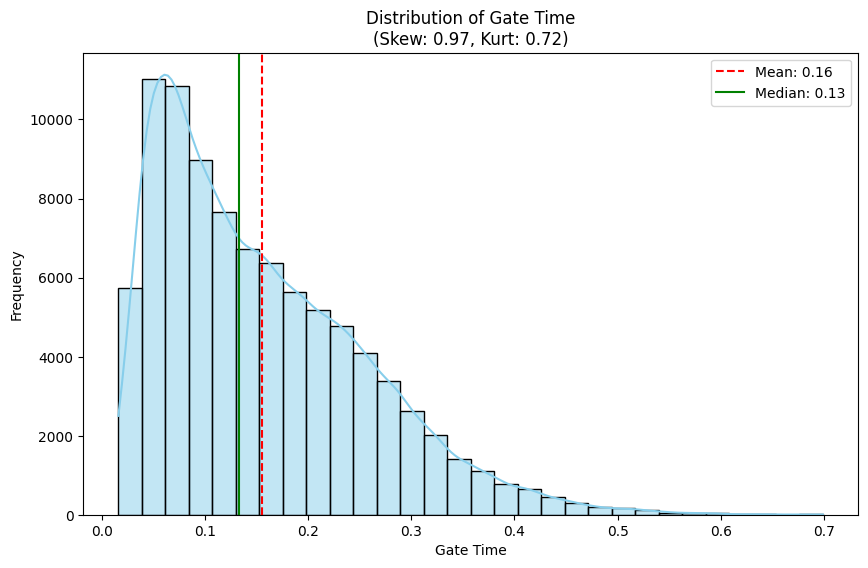

In [85]:
# 1. Basic Descriptive Statistics
stats = time_result['gate_time'].describe()
print("=== Basic Statistics ===")
print(stats)

# 2. Shape Statistics (Skewness & Kurtosis)
skewness = time_result['gate_time'].skew()
kurt = time_result['gate_time'].kurtosis()

print(f"\n=== Distribution Shape ===")
print(f"Skewness: {skewness:.4f} (0 = symmetric, positive = right tail)")
print(f"Kurtosis: {kurt:.4f} (3 = normal-like, high = heavy tails)")

# 3. Re-plotting with Mean and Median lines
plt.figure(figsize=(10, 6))
sns.histplot(time_result['gate_time'], kde=True, bins=30, color='skyblue')

# Add vertical lines for Mean and Median
plt.axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.2f}")
plt.axvline(stats['50%'], color='green', linestyle='-', label=f"Median: {stats['50%']:.2f}")

plt.title(f'Distribution of Gate Time\n(Skew: {skewness:.2f}, Kurt: {kurt:.2f})')
plt.xlabel('Gate Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

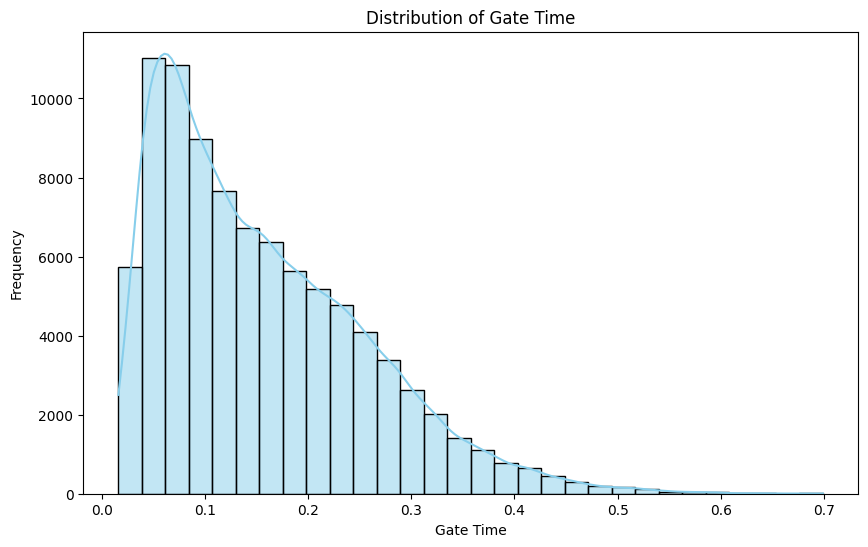

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(time_result['gate_time'], kde=True, bins=30, color='skyblue')

plt.title('Distribution of Gate Time')
plt.xlabel('Gate Time')
plt.ylabel('Frequency')
plt.show()

In [74]:
Q1 = time_result['gate_time'].quantile(0.25)
Q3 = time_result['gate_time'].quantile(0.75)
IQR = Q3 - Q1

# The standard statistical upper bound
iqr_threshold = Q3 + 1.5 * IQR

print(f"IQR Threshold: {iqr_threshold}")
# Likely around 0.44 based on your plot

IQR Threshold: 0.43823275342583645


In [75]:
# 1. To Remove Outliers (Clean the data)
clean_data = time_result[time_result['gate_time'] <= iqr_threshold]

# 2. To Flag them (Create a new column)
time_result['is_high_gate_time'] = time_result['gate_time'] > iqr_threshold

# Check how many you are removing
print(f"Original size: {len(time_result)}")
print(f"Cleaned size: {len(clean_data)}")

Original size: 90337
Cleaned size: 89231


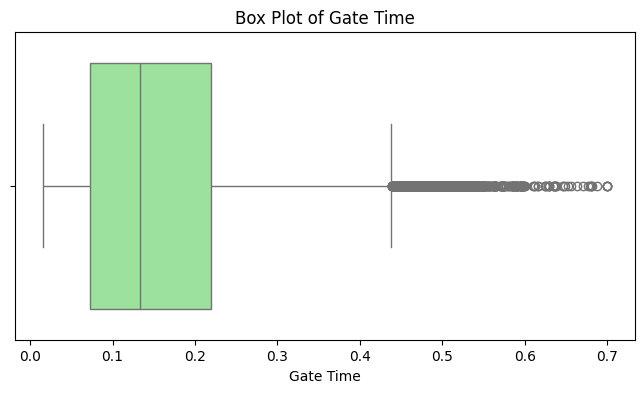

In [72]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=time_result['gate_time'], color='lightgreen')

plt.title('Box Plot of Gate Time')
plt.xlabel('Gate Time')
plt.show()

In [73]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = time_result['gate_time'].quantile(0.25)
Q3 = time_result['gate_time'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the bounds (standard boxplot uses 1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the data to find outliers
outliers = time_result[
    (time_result['gate_time'] < lower_bound) | 
    (time_result['gate_time'] > upper_bound)
]

# 5. Get the count
print(f"Total outliers: {len(outliers)}")

# Optional: See the actual values
# print(outliers['gate_time'])

Total outliers: 1106


In [83]:
import numpy as np

# 1. IQR Method
Q1 = time_result['gate_time'].quantile(0.25)
Q3 = time_result['gate_time'].quantile(0.75)
IQR = Q3 - Q1
thresh_iqr = Q3 + 1.5 * IQR

# 2. Percentile Method (e.g., 99%)
thresh_p99 = time_result['gate_time'].quantile(0.99)

# 3. Z-Score Method
mean = time_result['gate_time'].mean()
std = time_result['gate_time'].std()
thresh_z = mean + 3 * std

# Calculate Noise Ratios
total = len(time_result)

def calc_ratio(threshold, total_count):
    outliers = (time_result['gate_time'] > threshold).sum()
    return outliers, (outliers / total_count) * 100

n_iqr, ratio_iqr = calc_ratio(thresh_iqr, total)
n_p99, ratio_p99 = calc_ratio(thresh_p99, total)
n_z, ratio_z = calc_ratio(thresh_z, total)

print(f"--- Noise Ratios ---")
print(f"IQR Method (Thresh: {thresh_iqr:.3f}): Removed {n_iqr} ({ratio_iqr:.2f}%)")
print(f"P99 Method (Thresh: {thresh_p99:.3f}): Removed {n_p99} ({ratio_p99:.2f}%)")
print(f"Z-Score    (Thresh: {thresh_z:.3f}):   Removed {n_z} ({ratio_z:.2f}%)")

--- Noise Ratios ---
IQR Method (Thresh: 0.438): Removed 1106 (1.22%)
P99 Method (Thresh: 0.450): Removed 904 (1.00%)
Z-Score    (Thresh: 0.459):   Removed 777 (0.86%)


In [84]:
# 1. Show IQR Outliers
print(f"\n=== IQR Method Noise (Threshold > {thresh_iqr:.3f}) ===")
noise_iqr = time_result[time_result['gate_time'] > thresh_iqr]
# Display first 5 rows to avoid flooding console, or remove .head() to see all
print(noise_iqr.sort_values('gate_time', ascending=False).head()) 

# 2. Show P99 Outliers
print(f"\n=== P99 Method Noise (Threshold > {thresh_p99:.3f}) ===")
noise_p99 = time_result[time_result['gate_time'] > thresh_p99]
print(noise_p99.sort_values('gate_time', ascending=False).head())

# 3. Show Z-Score Outliers
print(f"\n=== Z-Score Method Noise (Threshold > {thresh_z:.3f}) ===")
noise_z = time_result[time_result['gate_time'] > thresh_z]
print(noise_z.sort_values('gate_time', ascending=False).head())


=== IQR Method Noise (Threshold > 0.438) ===
       true_time  pred_time  gate_time  is_high_gate_time
49959          5          5   0.699179               True
49703          5          5   0.699179               True
49192          5          5   0.699179               True
49447          5          8   0.699179               True
1841           7          8   0.687103               True

=== P99 Method Noise (Threshold > 0.450) ===
       true_time  pred_time  gate_time  is_high_gate_time
49447          5          8   0.699179               True
49192          5          5   0.699179               True
49703          5          5   0.699179               True
49959          5          5   0.699179               True
1841           7          8   0.687103               True

=== Z-Score Method Noise (Threshold > 0.459) ===
       true_time  pred_time  gate_time  is_high_gate_time
49192          5          5   0.699179               True
49959          5          5   0.699179        

In [65]:
CLASSIFICATION_MISSING_VALUE = -100

In [77]:
print(f"Mask length (from time_result): {len(clean_mask)}")
for task, values in test_ground_truths.items():
    print(f"Task '{task}' length: {len(values)}")

Mask length (from time_result): 90337
Task 'scale' length: 90337
Task 'negative' length: 90337
Task 'tag' length: 90337
Task 'time' length: 90337
Task 'fact' length: 89386


Original sample size: 90337
Clean sample size: 89231
Dropped 1106 outliers.
--- Evaluation on Cleaned Data ---

TIME Evaluation Metrics:
Weighted F1 Score: 0.7973
Weighted Recall: 0.7967
Weighted Precision: 0.8018
Accuracy: 0.7967
F1 Score (macro): 0.6192
Precision (macro): 0.6251
Recall (macro): 0.6163

Confusion Matrix:
[[14017   920    42  1371   132    12   160     0     0]
 [ 2530 18770   140   339  1132    46   916     0     5]
 [  135    92  1854    26    27   147    15     0     0]
 [ 2468   194     7 17491   593    34   575     0     1]
 [  430  1424    32  1269 11309   120   397     0     1]
 [   45    27    97    95    79   705    43     1     8]
 [  283   553     7   817   222    18  6725     0     2]
 [    0     2     2     0     9    11     2     0     4]
 [    3     4     0     4     5     2    12     0     4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.77     16654
           1       0.85      

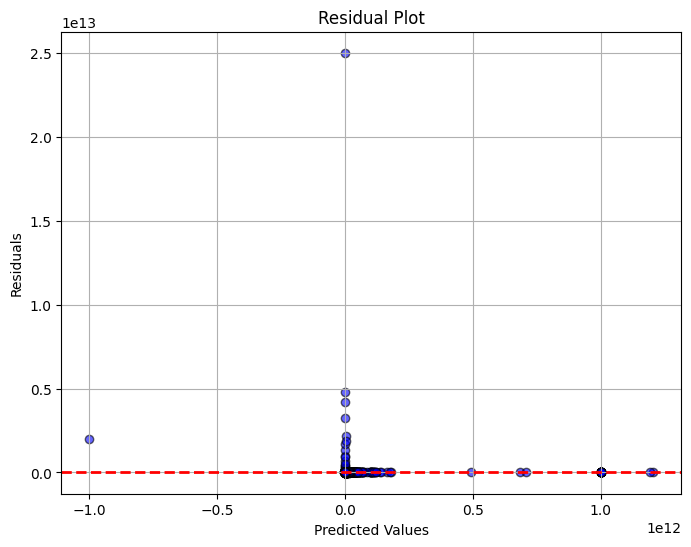


TAG Evaluation Metrics:
Weighted F1 Score: 0.5983
Weighted Recall: 0.6239
Weighted Precision: 0.6029
Accuracy: 0.6239
F1 Score (macro): 0.3784
Precision (macro): 0.4309
Recall (macro): 0.4024

Confusion Matrix:
[[17243  1766    85 ...     0     3     0]
 [ 2625  3717    34 ...     0     3     0]
 [   57     3  1492 ...     0     0     0]
 ...
 [    1     4     0 ...     0     0     0]
 [    6     0     0 ...     0     3     0]
 [    8     0     0 ...     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68     24144
           1       0.49      0.41      0.45      9031
           2       0.83      0.91      0.87      1644
           3       0.84      0.88      0.86      1274
           4       0.57      0.77      0.65      1334
           5       0.68      0.84      0.75      1228
           6       0.69      0.96      0.80      1030
           7       0.83      0.90      0.86       802
           8 

In [79]:
import numpy as np

# 1. Re-calculate the threshold (Using IQR method as discussed)
Q1 = time_result['gate_time'].quantile(0.25)
Q3 = time_result['gate_time'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# 2. Create a boolean mask for valid (clean) rows
# This creates a list of True/False values where True = Keep, False = Outlier
clean_mask = time_result['gate_time'] <= upper_bound

print(f"Original sample size: {len(time_result)}")
print(f"Clean sample size: {clean_mask.sum()}")
print(f"Dropped {len(time_result) - clean_mask.sum()} outliers.")

# 3. Helper function to apply the mask to your dictionaries
def filter_dictionary(data_dict, mask):
    cleaned_dict = {}
    for task, values in data_dict.items():
        # Convert to numpy array to use boolean indexing, then apply mask
        cleaned_dict[task] = np.array(values)[mask]
    return cleaned_dict
import numpy as np

# 1. Standard mask for the matching tasks (length 90,337)
clean_mask = time_result['gate_time'] <= upper_bound

# 2. Filter the matching tasks (scale, negative, tag, time)
clean_ground_truths = {}
clean_predictions = {}

for task in ['scale', 'negative', 'tag', 'time']:
    clean_ground_truths[task] = np.array(test_ground_truths[task])[clean_mask]
    clean_predictions[task] = np.array(test_predictions[task])[clean_mask]

# 3. Special handling for 'fact' (length 89,386)
# We slice the mask to match the length of 'fact'
fact_len = len(test_ground_truths['fact'])
fact_mask = clean_mask.iloc[:fact_len] # Taking the first 89,386 values of the mask

clean_ground_truths['fact'] = np.array(test_ground_truths['fact'])[fact_mask]
clean_predictions['fact'] = np.array(test_predictions['fact'])[fact_mask]

# 4. Run Evaluation
print("--- Evaluation on Cleaned Data ---")
time_metrics = evaluate_classification(clean_ground_truths['time'], clean_predictions['time'], 'time')
scale_metrics = evaluate_classification(clean_ground_truths['scale'], clean_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(clean_ground_truths['negative'], clean_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(clean_ground_truths['fact'], clean_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(clean_ground_truths['tag'], clean_predictions['tag'], 'tag')

In [ ]:
# time_metrics = evaluate_classification(time_result['true_time'].tolist(), time_result['pred_time'].tolist(), 'time')
# scale_metrics = evaluate_classification(scale_result['true_scale'].tolist(), scale_result['pred_scale'].tolist(), 'scale')
# negative_metrics = evaluate_classification(negative_result['true_negative'], negative_result['pred_negative'], 'negative')
# tag_metrics = evaluate_classification(tag_result['true_tag'], tag_result['pred_tag'], 'tag')



TIME Evaluation Metrics:
Weighted F1 Score: 0.7925
Weighted Recall: 0.7917
Weighted Precision: 0.7972
Accuracy: 0.7917
F1 Score (macro): 0.6216
Precision (macro): 0.6210
Recall (macro): 0.6249

Confusion Matrix:
[[14056   926    49  1381   135    22   171     0     2]
 [ 2564 18853   159   350  1145    83   948     1     9]
 [  147   105  1873    30    30   176    23     0     2]
 [ 2488   200    13 17542   598    60   606     1     6]
 [  442  1449    41  1298 11343   170   429     1     5]
 [   48    37   115    98    86   830    51     1    16]
 [  287   570     7   831   223    28  6798     0     8]
 [    0     2     3     0     9    14     2     0     9]
 [    3     6     0    11     6     6    17     1    15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76     16742
           1       0.85      0.78      0.82     24112
           2       0.83      0.78      0.81      2386
           3       0.81      0.8


TIME Evaluation Metrics:
Weighted F1 Score: 0.7925
Weighted Recall: 0.7917
Weighted Precision: 0.7972
Accuracy: 0.7917
F1 Score (macro): 0.6216
Precision (macro): 0.6210
Recall (macro): 0.6249

Confusion Matrix:
[[14056   926    49  1381   135    22   171     0     2]
 [ 2564 18853   159   350  1145    83   948     1     9]
 [  147   105  1873    30    30   176    23     0     2]
 [ 2488   200    13 17542   598    60   606     1     6]
 [  442  1449    41  1298 11343   170   429     1     5]
 [   48    37   115    98    86   830    51     1    16]
 [  287   570     7   831   223    28  6798     0     8]
 [    0     2     3     0     9    14     2     0     9]
 [    3     6     0    11     6     6    17     1    15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76     16742
           1       0.85      0.78      0.82     24112
           2       0.83      0.78      0.81      2386
           3       0.81      0.8

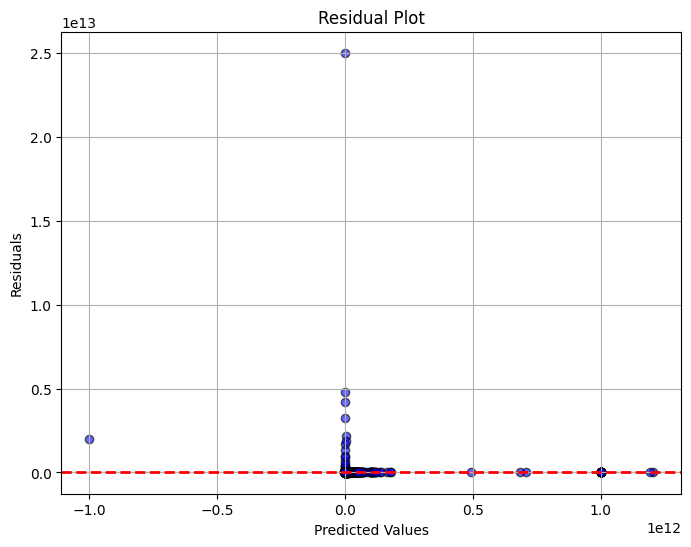


TAG Evaluation Metrics:
Weighted F1 Score: 0.5977
Weighted Recall: 0.6234
Weighted Precision: 0.6022
Accuracy: 0.6234
F1 Score (macro): 0.3785
Precision (macro): 0.4312
Recall (macro): 0.4022

Confusion Matrix:
[[17659  1792    86 ...     0     3     0]
 [ 2689  3769    34 ...     0     3     0]
 [   57     3  1494 ...     0     0     0]
 ...
 [    1     4     0 ...     0     0     0]
 [    6     0     0 ...     0     3     0]
 [    8     0     0 ...     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.72      0.68     24644
           1       0.49      0.41      0.45      9175
           2       0.83      0.91      0.87      1646
           3       0.84      0.89      0.86      1289
           4       0.57      0.77      0.65      1341
           5       0.68      0.84      0.75      1228
           6       0.69      0.96      0.80      1030
           7       0.83      0.90      0.86       802
           8 

In [81]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')


# threshold

In [38]:
import torch
import numpy as np
from collections import defaultdict
import pandas as pd

def evaluate_model_with_gate_filter(model, test_loader, device, gate_threshold=0.5):
    """
    Evaluates the model but only on samples where gate_value <= threshold.
    Returns metrics for the 'clean' subset and the coverage percentage.
    """
    # 1. Ensure Model is on the correct device
    model.to(device) 
    model.eval()
    
    # Storage for filtered results
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    
    # Counters
    total_samples = 0
    kept_samples = 0
    
    # Scale conversion map (Re-creating it here to be safe)
    # Ensure id2scale is available globally or passed as an argument. 
    # If id2scale is global:
    id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)

    with torch.no_grad():
        for batch in test_loader:
            # 2. Move Inputs to Device (CRITICAL STEP)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            # 3. Move Targets to Device
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            # Forward Pass
            # The error happened here because input_ids might have been on CPU
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # --- GATE FILTERING LOGIC ---
            # Gate output shape: [batch_size, 1] -> flatten to [batch_size]
            gate_values = outputs["gate"].squeeze(-1).cpu().numpy()
            
            # Get predictions for processing
            batch_preds = {}
            for key in ["tag", "time", "scale", "negative"]:
                # Move to CPU immediately for numpy processing
                batch_preds[key] = torch.argmax(outputs[key], dim=-1).cpu().numpy()
            
            # Process Fact Prediction (Vectorized for batch)
            neg_pred = batch_preds["negative"]
            scale_idx = batch_preds["scale"]
            scale_val = id2scale_np[scale_idx]
            vals = values.cpu().numpy()
            
            # Formula: value * (-1)^neg * 10^scale
            fact_preds = vals * ((-1) ** neg_pred) * (10 ** scale_val)

            # Move targets to CPU for storage
            batch_targets = {k: v.cpu().numpy() for k, v in targets.items()}

            # Iterate through the batch to filter individual samples
            batch_size = input_ids.size(0)
            for i in range(batch_size):
                total_samples += 1
                
                # Check Gate: If gate is high, it is NOISE. We want CLEAN (Low gate).
                # Logic: Keep sample if gate_value <= threshold
                if gate_values[i] > gate_threshold:
                    continue # Skip this sample (Filtered out)
                
                kept_samples += 1
                
                # Store Data for this sample
                # 1. Classification Attributes
                for key in ["tag", "time", "scale", "negative"]:
                    t = batch_targets[key][i]
                    # Skip missing values (-100)
                    if t != -100:
                        predictions[key].append(batch_preds[key][i])
                        ground_truths[key].append(t)
                
                # 2. Fact Regression
                if "fact" in batch_targets:
                    t_fact = batch_targets["fact"][i]
                    # Check for float max (missing value)
                    if t_fact < 1e30: 
                        predictions["fact"].append(fact_preds[i])
                        ground_truths["fact"].append(t_fact)

    # Calculate Coverage
    coverage = kept_samples / total_samples if total_samples > 0 else 0
    
    return predictions, ground_truths, coverage

In [39]:
import pandas as pd

# Load Model
# Ensure model is loaded and on device as per your previous code
# model.load_state_dict(torch.load(model_save_path))

thresholds = [ 0.5, 0.75, 0.9 ]
results_log = []

print(f"{'Threshold':<10} | {'Coverage':<10} | {'Tag Acc':<10} | {'Fact RMSE':<10} | {'Fact MAE':<10}")
print("-" * 65)

for thresh in thresholds:
    # 1. Run Filtered Evaluation
    preds, truths, coverage = evaluate_model_with_gate_filter(
        model, test_loader, device, gate_threshold=thresh
    )
    
    # 2. Compute Metrics (Reuse your existing evaluate functions)
    # Calculate Tag Accuracy (Example)
    if preds['tag']:
        tag_metrics = evaluate_classification(truths['tag'], preds['tag'], 'tag')
        tag_acc = tag_metrics['accuracy']
    else:
        tag_acc = 0.0

    # Calculate Fact Metrics (Example)
    if preds['fact']:
        # Note: evaluate_regression prints output, you might want to suppress it or return dict
        # Assuming we just want the numbers:
        fact_rmse = np.sqrt(mean_squared_error(truths['fact'], preds['fact']))
        fact_mae = mean_absolute_error(truths['fact'], preds['fact'])
    else:
        fact_rmse = 0.0
        fact_mae = 0.0
        
    # 3. Log Result
    print(f"{thresh:<10.1f} | {coverage:<10.2%} | {tag_acc:<10.4f} | {fact_rmse:<10.4f} | {fact_mae:<10.4f}")
    
    results_log.append({
        "threshold": thresh,
        "coverage": coverage,
        "tag_acc": tag_acc,
        "fact_rmse": fact_rmse,
        "fact_mae": fact_mae
    })

# Save trade-off results to CSV
df_tradeoff = pd.DataFrame(results_log)
df_tradeoff.to_csv(f"gate_tradeoff_{model_name}_{date}_{index}.csv", index=False)

Threshold  | Coverage   | Tag Acc    | Fact RMSE  | Fact MAE  
-----------------------------------------------------------------

TAG Evaluation Metrics:
Weighted F1 Score: 0.0004
Weighted Recall: 0.0019
Weighted Precision: 0.0093
Accuracy: 0.0019
F1 Score (macro): 0.0001
Precision (macro): 0.0007
Recall (macro): 0.0012

Confusion Matrix:
[[  0   0   2 ... 372   0   0]
 [  0   0   0 ...  63   0   0]
 [  0   0   1 ... 201   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4975
           1       0.00      0.00      0.00      1642
           2       0.25      0.00      0.00       478
           3       0.00      0.00      0.00       147
           4       0.00      0.00      0.00       305
           5       0.00      0.00      0.00        70
           6       0.00      0.00      0.00        90
          

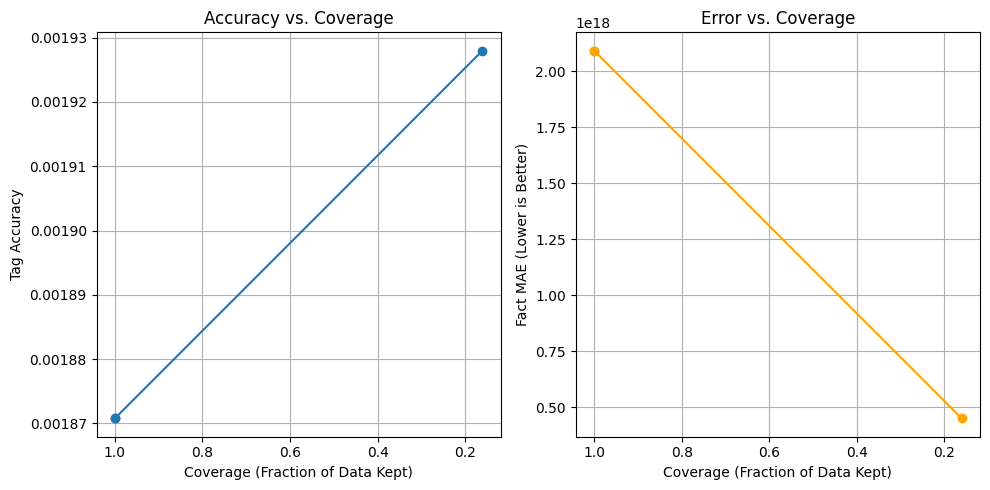

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot 1: Tag Accuracy vs Coverage
plt.subplot(1, 2, 1)
plt.plot(df_tradeoff['coverage'], df_tradeoff['tag_acc'], marker='o', linestyle='-')
plt.xlabel('Coverage (Fraction of Data Kept)')
plt.ylabel('Tag Accuracy')
plt.title('Accuracy vs. Coverage')
plt.grid(True)
plt.gca().invert_xaxis() # Usually viewed as coverage decreasing from 1.0 -> 0.0

# Plot 2: Fact MAE vs Coverage
plt.subplot(1, 2, 2)
plt.plot(df_tradeoff['coverage'], df_tradeoff['fact_mae'], marker='o', color='orange', linestyle='-')
plt.xlabel('Coverage (Fraction of Data Kept)')
plt.ylabel('Fact MAE (Lower is Better)')
plt.title('Error vs. Coverage')
plt.grid(True)
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()